<a href="https://colab.research.google.com/github/jmmarinr/ComputationalMethods/blob/master/EDO/Euler_Primer_Segundo_Orden.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
#@title Librerias
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# **Ecuaciones Diferenciales Ordinarias (EDO)**  

---

Prof. **Juan Marcos Marín Ramírez**

---

Una **ecuación diferencial ordinaria (EDO)** es una ecuación que involucra una función desconocida y sus derivadas respecto a una única variable independiente. Se usan ampliamente en la modelación matemática de fenómenos físicos, biológicos y de ingeniería.

## **Forma General**  
Una EDO puede expresarse como:

$$
F(x, y, y', y'', ..., y^{(n)}) = 0
$$

donde:
- $x$ es la variable independiente.
- $y = y(x)$ es la función desconocida.
- $y', y'', ..., y^{(n)}$ son las derivadas de $y$ con respecto a $x$.
- $F$ es una función que relaciona estas cantidades.

---

## **Clasificación de las EDO**  

Las EDO pueden clasificarse en distintas categorías:

### **1. Según su Orden**  
El **orden** de una EDO es el mayor grado de derivada presente en la ecuación.

- **Primer orden:** Contiene solo la primera derivada.
  $$
  y' + p(x)y = g(x)
  $$
- **Segundo orden:** Contiene hasta la segunda derivada.
  $$
  y'' + p(x)y' + q(x)y = g(x)
  $$
- **Orden $n$:** Contiene derivadas hasta el orden $n$.
  $$
  y^{(n)} + a_{n-1}(x)y^{(n-1)} + ... + a_1(x)y' + a_0(x)y = g(x)
  $$

---

### **2. Según su Linealidad**  
Una EDO puede ser **lineal** o **no lineal**:

- **Lineales:** La función $y$ y sus derivadas aparecen con coeficientes que dependen solo de $x$.
  $$
  y'' + 2xy' + 3y = x^2
  $$
- **No lineales:** Aparecen términos no lineales de $y$ o sus derivadas, como potencias, productos, senos, cosenos, exponenciales, etc.
  $$
  y' = y^2 + \sin(y)
  $$

---

### **3. Según su Homogeneidad**  
- **Homogéneas:** No hay un término independiente en la ecuación.
  $$
  y'' + y = 0
  $$
- **No homogéneas:** Hay un término independiente distinto de cero.
  $$
  y'' + y = x
  $$

---

### **4. Según su Autonomía**  
- **Autónomas:** No dependen explícitamente de $x$.
  $$
  y' = y(1 - y)
  $$
- **No autónomas:** Dependen explícitamente de $x$.
  $$
  y' = x + y^2
  $$

---

## **Ejemplos de Sistemas Físicos Modelados con EDO**  

Las EDO aparecen en muchos fenómenos físicos. Aquí hay algunos ejemplos sin resolver:

### **1. Movimiento de un Péndulo Simple (EDO de Segundo Orden, No Lineal)**
$$
\theta'' + \frac{g}{L} \sin\theta = 0
$$
Modela el movimiento oscilatorio de un péndulo simple bajo la acción de la gravedad.

---

### **2. Ley de Enfriamiento de Newton (EDO de Primer Orden, Lineal)**
$$
\frac{dT}{dt} = -k(T - T_a)
$$
Describe cómo un objeto pierde calor en un ambiente con temperatura $T_a$.

---

### **3. Oscilador Armónico (EDO de Segundo Orden, Lineal)**
$$
m x'' + kx = 0
$$
Modela el movimiento de un resorte ideal sin amortiguamiento.

---

### **4. Circuito RLC (EDO de Segundo Orden, Lineal)**
$$
L\frac{d^2Q}{dt^2} + R\frac{dQ}{dt} + \frac{Q}{C} = 0
$$
Describe la evolución de la carga en un circuito eléctrico con resistencia, inductancia y capacitancia.

---

### **5. Crecimiento Poblacional (EDO de Primer Orden, No Lineal)**
$$
\frac{dN}{dt} = rN(1 - \frac{N}{K})
$$
Modelo logístico de crecimiento poblacional con capacidad de carga $K$.

---

Cada una de estas ecuaciones describe un fenómeno físico importante y requiere métodos específicos para su solución, dependiendo de su complejidad.

# Método de Euler para Ecuaciones Diferenciales Ordinarias

## Derivación del método

El método de Euler se basa en la aproximación de una función mediante su expansión en series de Taylor. Para una función $y(x)$ que satisface la ecuación diferencial:

$$\frac{dy}{dx} = f(x,y)$$

Con la condición inicial $y(x_0) = y_0$, podemos usar la expansión de Taylor alrededor de $x_n$ para encontrar el valor de $y$ en el punto $x_{n+1} = x_n + h$:

$$y(x_{n+1}) = y(x_n) + \frac{dy}{dx}(x_n) \cdot h + \frac{1}{2}\frac{d^2y}{dx^2}(x_n) \cdot h^2 + \frac{1}{6}\frac{d^3y}{dx^3}(x_n) \cdot h^3 + \ldots$$

Si truncamos esta serie después del término lineal, obtenemos:

$$y(x_{n+1}) \approx y(x_n) + \frac{dy}{dx}(x_n) \cdot h$$

Pero sabemos que $\frac{dy}{dx} = f(x,y)$, por lo tanto:

$$y(x_{n+1}) \approx y(x_n) + f(x_n, y_n) \cdot h$$

Esta es la fórmula del método de Euler, donde:
- $h$ es el tamaño del paso
- $y_n$ es la aproximación numérica de $y(x_n)$
- $y_{n+1}$ es la aproximación numérica de $y(x_{n+1})$



## Ejemplo

Resolviendo $$\frac{dy}{dx} = y$$
con $y(0) = 1$

Para este ejemplo, sabemos que la solución analítica es $y(x) = e^x$, lo que nos permitirá evaluar la precisión del método.

### Parámetros:
- Ecuación: $\frac{dy}{dx} = y$, es decir, $f(x,y) = y$
- Condición inicial: $y(0) = 1$
- Intervalo: $[0, 1]$
- Tamaño del paso: $h = 0.2$ (5 pasos)

### Aplicación del método:

Para cada paso aplicamos la fórmula $y_{n+1} = y_n + h \cdot f(x_n, y_n)$

| $n$ | $x_n$ | $y_n$ | $f(x_n, y_n) = y_n$ | $h \cdot f(x_n, y_n)$ | $y_{n+1} = y_n + h \cdot f(x_n, y_n)$ | Valor exacto: $e^{x_n}$ | Error absoluto |
|-----|-------|-------|----------------------|------------------------|----------------------------------------|--------------------------|---------------|
| 0   | 0.0   | 1.0   | 1.0                  | 0.2                    | 1.2                                    | 1.0                      | 0.0           |
| 1   | 0.2   | 1.2   | 1.2                  | 0.24                   | 1.44                                   | 1.2214                   | 0.0214        |
| 2   | 0.4   | 1.44  | 1.44                 | 0.288                  | 1.728                                  | 1.4918                   | 0.0518        |
| 3   | 0.6   | 1.728 | 1.728                | 0.3456                 | 2.0736                                 | 1.8221                   | 0.0941        |
| 4   | 0.8   | 2.0736| 2.0736               | 0.41472                | 2.48832                                | 2.2255                   | 0.1519        |
| 5   | 1.0   | 2.48832| -                   | -                      | -                                      | 2.7183                   | 0.2300        |

## Interpretación geométrica

El método de Euler tiene una interpretación geométrica muy intuitiva:

1. En cada punto $(x_n, y_n)$, calculamos la pendiente de la función según la ecuación diferencial: $f(x_n, y_n)$
2. Avanzamos una distancia $h$ en la dirección de esta pendiente, obteniendo la aproximación $(x_{n+1}, y_{n+1})$
3. Repetimos el proceso

Esto significa que estamos aproximando la curva solución mediante segmentos de recta tangentes a la curva en cada punto de la aproximación.

![Euler](https://upload.wikimedia.org/wikipedia/commons/1/10/Euler_method.svg)


In [6]:
def Euler(f, x0, y0, h, x_end):
    """
    Implementa el método de Euler para resolver una Ecuación Diferencial Ordinaria (EDO) de primer orden.
    y(xn + 1) = y(xn) + h * f(xn, yn)

    Args:
        f: La función que define la EDO, dy/dx = f(x, y). Debe aceptar dos argumentos: x e y. -> Callable
        x0: La condición inicial para la variable independiente (x). -> float
        y0: La condición inicial para la variable dependiente (y) en x0. -> float
        h: El tamaño del paso (incremento en x) para la iteración. -> float
        x_end: El valor final de x hasta donde se desea aproximar la solución. -> float

    Returns:
        Una tupla (x, y) donde:
        x: Un arreglo numpy con los valores de x en cada paso. -> Array
        y: Un arreglo numpy con las aproximaciones de y correspondientes a cada valor de x. -> Array
    """
    # Calcular el número de pasos necesarios para ir de x0 a x_end con un tamaño de paso h.
    n_steps = int((x_end - x0) / h)

    # Inicializar arreglos numpy para almacenar los valores de x e y en cada paso.
    # Se crea un espacio para n_steps + 1 puntos, incluyendo el punto inicial.
    x = np.zeros(n_steps + 1)
    y = np.zeros(n_steps + 1)

    # Establecer la condición inicial en el primer elemento de los arreglos.
    x[0] = x0
    y[0] = y0

    # Iterar sobre el número de pasos para aplicar la fórmula del método de Euler.
    for i in range(n_steps):
        # Calcular el siguiente valor de x sumando el tamaño del paso h al valor actual de x.
        x[i+1] = x[i] + h
        # Aplicar la fórmula del método de Euler para calcular la aproximación del siguiente valor de y:
        # y[i+1] = y[i] + h * f(x[i], y[i])
        # donde f(x[i], y[i]) es la pendiente en el punto actual (x[i], y[i]) según la EDO.
        y[i+1] = y[i] + h * f(x[i], y[i])

    # Devolver los arreglos de valores de x e y calculados.
    return x, y

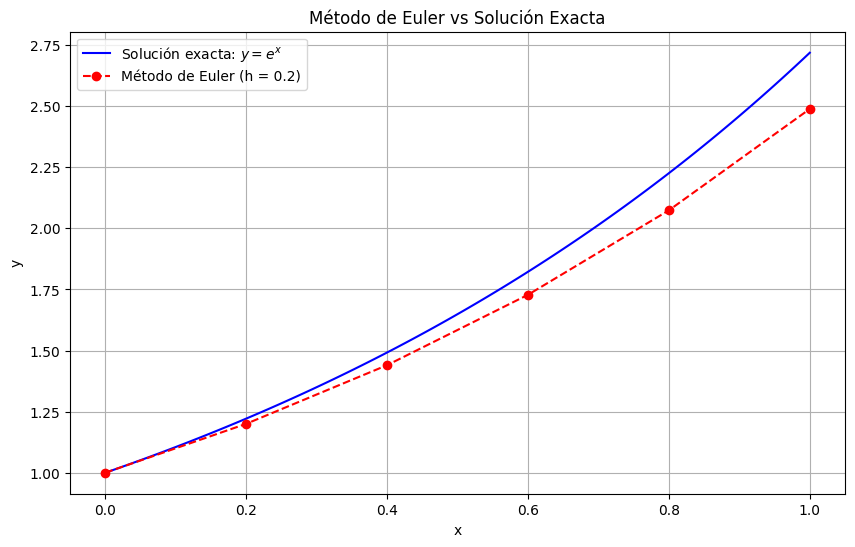

In [7]:
# Definir la EDO: dy/dx = y
f = lambda x, y: y

# Condiciones iniciales y parámetros
x0, y0 = 0, 1
h = 0.2
x_end = 1

# Aplicar método de Euler
x, y_euler = Euler(f, x0, y0, h, x_end)

# Calcular solución exacta
x_exact = np.linspace(x0, x_end, 100)
y_exact = np.exp(x_exact)

# Visualizar resultados
plt.figure(figsize=(10, 6))
plt.plot(x_exact, y_exact, 'b-', label='Solución exacta: $y = e^x$')
plt.plot(x, y_euler, 'ro--', label=f'Método de Euler (h = {h})')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Método de Euler vs Solución Exacta')
plt.grid(True)
plt.legend()
plt.show()

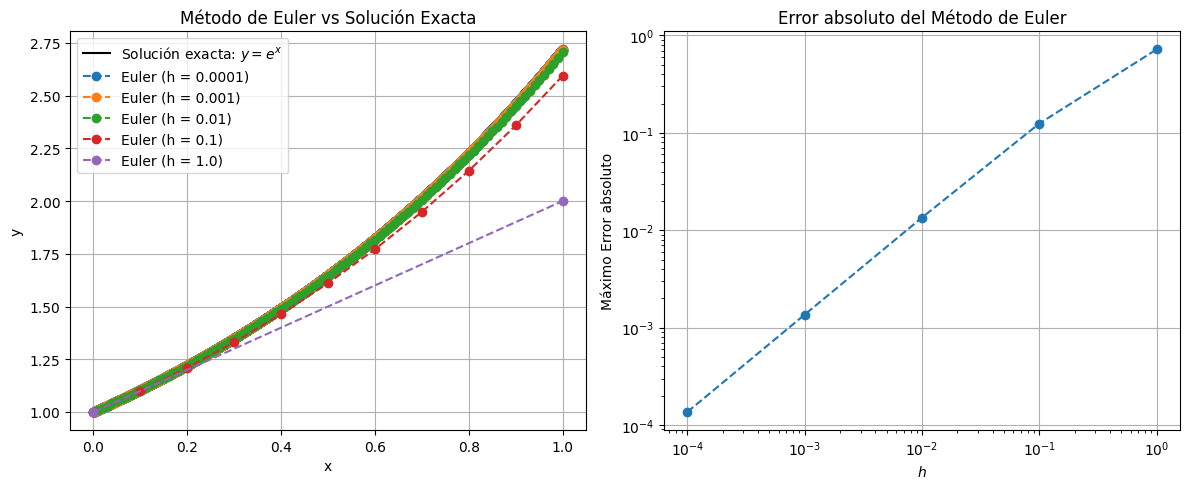

In [13]:

# Definir la EDO: dy/dx = y
f = lambda x, y: y

# Condiciones iniciales y parámetros
x0, y0 = 0, 1
x_end = 1
h_values = np.logspace(-4, 0, 5)  # Valores de h en escala logarítmica

# Calcular solución exacta
x_exact = np.linspace(x0, x_end, 100)
y_exact = lambda x: np.exp(x)

plt.figure(figsize=(12, 5))

# Gráfico de soluciones
plt.subplot(1, 2, 1)
plt.plot(x_exact, y_exact(x_exact), 'k-', label='Solución exacta: $y = e^x$')

for h in h_values:
    x, y_euler = Euler(f, x0, y0, h, x_end)
    plt.plot(x, y_euler, 'o--', label=f'Euler (h = {h})')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Método de Euler vs Solución Exacta')
plt.grid(True)
plt.legend()

# Gráfico de error absoluto
error_abs = np.zeros_like(h_values)

plt.subplot(1, 2, 2)
for i, h in enumerate(h_values):
    x, y_euler = Euler(f, x0, y0, h, x_end)
    error_abs[i] = max(np.abs(y_exact(x) - y_euler))

plt.loglog(h_values, error_abs, 'o--')
plt.xlabel('$h$')
plt.ylabel('Máximo Error absoluto')
plt.title('Error absoluto del Método de Euler')
plt.grid(True)

plt.tight_layout()
plt.show()

# Solución de EDO usando `sympy`

In [14]:
# Símbolos y función
t = sp.symbols('t')
y = sp.Function('y')

# EDO: y' = y
edo = sp.Eq(sp.diff(y(t), t), y(t))

# Resolver el PVI con la condición inicial y(0)=1
sol_particular = sp.dsolve(edo, ics={y(t).subs(t, 0): 1})

# Mostrar (preferentemente en un notebook usar display)
display(sol_particular)

Eq(y(t), exp(t))

# Error de truncamiento y estabilidad del método de Euler

## Error de truncamiento

El error de truncamiento en el método de Euler surge al considerar solo el primer término de la expansión de Taylor, ignorando los términos de orden superior. Veamos esto en detalle:

### Error local

El error local de truncamiento (ELT) es el error cometido en un solo paso, asumiendo que partimos del valor exacto. Para derivarlo, recordemos la expansión de Taylor de $y(x_{n+1})$ alrededor de $x_n$:

$$y(x_{n+1}) = y(x_n) + h \cdot \frac{dy}{dx}(x_n) + \frac{h^2}{2} \cdot \frac{d^2y}{dx^2}(x_n) + O(h^3)$$

El método de Euler usa solo:
$$y_{n+1} = y_n + h \cdot f(x_n, y_n)$$

Por lo tanto, el error local es:
$$\text{ELT} = \frac{h^2}{2} \cdot \frac{d^2y}{dx^2}(x_n) + O(h^3)$$

Esto nos dice que el error local es proporcional a $h^2$, lo que clasifica al método de Euler como un método de primer orden.

### Error global

El error global de truncamiento (EGT) es el error acumulado después de todos los pasos. Como realizamos aproximadamente $\frac{b-a}{h}$ pasos para cubrir un intervalo $[a, b]$, y en cada paso cometemos un error proporcional a $h^2$, el error global es:

$$\text{EGT} \approx \frac{b-a}{h} \cdot O(h^2) = O(h)$$

Esto significa que el error global es proporcional a $h$, por lo que reducir el tamaño del paso a la mitad teóricamente reduce el error global aproximadamente a la mitad.

## Estabilidad del método de Euler

La estabilidad analiza cómo pequeñas perturbaciones o errores se propagan a lo largo de la solución numérica.

### Región de estabilidad absoluta

Para ilustrar la estabilidad, consideremos la ecuación de prueba:
$$\frac{dy}{dx} = \lambda y$$

donde $\lambda$ es un número complejo. Aplicando Euler:
$$y_{n+1} = y_n + h\lambda y_n = (1 + h\lambda)y_n$$

Después de $n$ pasos:
$$y_n = (1 + h\lambda)^n y_0$$

Para que el método sea estable, necesitamos que $|1 + h\lambda| < 1$, lo que define la región de estabilidad absoluta en el plano complejo.

### Implicaciones prácticas de la estabilidad

1. **Para problemas con $\lambda$ real negativo (ecuaciones "stiff"):**
   - Euler explícito es estable solo si $h < \frac{2}{|\lambda|}$
   - Esta restricción puede ser muy severa para ecuaciones "stiff" (donde $|\lambda|$ es grande)
   - En estos casos, se necesitan pasos extremadamente pequeños, lo que hace ineficiente el método

2. **Para problemas oscilatorios ($\lambda$ imaginario):**
   - El método de Euler explícito siempre amplifica la magnitud de la solución
   - Esto introduce errores que crecen con el tiempo
   - Para estas ecuaciones, el método es condicionalmente estable

### Ejemplo ilustrativo de inestabilidad

Si aplicamos el método de Euler a $$\frac{dy}{dx} = -50y$$

con $y(0) = 1$ e $h = 0.05$:


Como $h\lambda = 0.05 \times (-50) = -2.5$, tenemos que $|1 + h\lambda| = |1 - 2.5| = 1.5 > 1$

Entonces:
- $y_1 = (1 - 2.5)y_0 = -1.5$
- $y_2 = (1 - 2.5)y_1 = -1.5 \times (-1.5) = 2.25$
- $y_3 = (1 - 2.5)y_2 = -1.5 \times 2.25 = -3.375$

La solución analítica $y = e^{-50x}$ decrece monótonamente, pero nuestra solución oscila con amplitud creciente. Este comportamiento inestable ocurre porque el paso $h$ es demasiado grande para este problema.


# Método de Euler para ecuaciones diferenciales de segundo orden

El método de Euler puede adaptarse para resolver ecuaciones diferenciales de segundo orden, aunque requiere una transformación previa.

## Transformación a sistema de primer orden

Una ecuación diferencial de segundo orden tiene la forma general:
$$\frac{d^2y}{dx^2} = f\left(x, y, \frac{dy}{dx}\right)$$

Para aplicar el método de Euler, primero necesitamos transformarla en un sistema de dos ecuaciones diferenciales de primer orden mediante las siguientes sustituciones:

$$y_1 = y$$
$$y_2 = \frac{dy}{dx}$$

Esto nos lleva al sistema:
$$\frac{dy_1}{dx} = y_2$$
$$\frac{dy_2}{dx} = f(x, y_1, y_2)$$

## Aplicación del método de Euler

Ahora aplicamos el método de Euler al sistema de ecuaciones de primer orden:

$$y_{1,n+1} = y_{1,n} + h \cdot y_{2,n}$$
$$y_{2,n+1} = y_{2,n} + h \cdot f(x_n, y_{1,n}, y_{2,n})$$

donde:
- $h$ es el tamaño del paso
- $x_{n+1} = x_n + h$
- $y_{1,n}$ es la aproximación de $y$ en $x_n$
- $y_{2,n}$ es la aproximación de $\frac{dy}{dx}$ en $x_n$

## Ejemplo: Oscilador armónico

Consideremos la ecuación diferencial que describe un oscilador armónico simple:
$$\frac{d^2y}{dx^2} + y = 0$$

Esta ecuación puede reescribirse como:
$$\frac{d^2y}{dx^2} = -y$$

### Paso 1: Convertir a sistema de primer orden

Hacemos las sustituciones:
$$y_1 = y$$
$$y_2 = \frac{dy}{dx}$$

Obteniendo el sistema:
$$\frac{dy_1}{dx} = y_2$$
$$\frac{dy_2}{dx} = -y_1$$

### Paso 2: Condiciones iniciales

Supongamos las condiciones iniciales:
- $y(0) = 0$ (posición inicial)
- $\frac{dy}{dx}(0) = 1$ (velocidad inicial)

Esto se traduce a:
- $y_1(0) = 0$
- $y_2(0) = 1$

### Paso 3: Aplicar el método de Euler

Con un tamaño de paso $h = 0.1$ y un intervalo $[0, 1]$, tenemos:

| $n$ | $x_n$ | $y_{1,n}$ (posición) | $y_{2,n}$ (velocidad) | $h \cdot y_{2,n}$ | $h \cdot (-y_{1,n})$ | $y_{1,n+1}$ | $y_{2,n+1}$ |
|-----|-------|----------------------|------------------------|-------------------|----------------------|-------------|-------------|
| 0   | 0.0   | 0.0                  | 1.0                    | 0.1               | 0.0                  | 0.1         | 1.0         |
| 1   | 0.1   | 0.1                  | 1.0                    | 0.1               | -0.01                | 0.2         | 0.99        |
| 2   | 0.2   | 0.2                  | 0.99                   | 0.099             | -0.02                | 0.299       | 0.97        |
| 3   | 0.3   | 0.299                | 0.97                   | 0.097             | -0.0299              | 0.396       | 0.9401      |
| 4   | 0.4   | 0.396                | 0.9401                 | 0.09401           | -0.0396              | 0.49001     | 0.9005      |
| 5   | 0.5   | 0.49001              | 0.9005                 | 0.09005           | -0.049001            | 0.58006     | 0.85150     |

La solución analítica para este problema es $y(x) = \sin(x)$, y podemos ver que nuestra aproximación numérica comienza a desviarse.



In [16]:
def Euler_orden2(f, t0, y0, yp0, h, t_end):
    """
    Implementa el método de Euler para resolver una Ecuación Diferencial Ordinaria (EDO) de segundo orden.

    Se considera una EDO de la forma:
        d²y/dt² = f(t, y, dy/dt)
    que se transforma en un sistema de primer orden:
        dy/dt = v
        dv/dt = f(t, y, v)

    Args:
        f: La función que define la segunda derivada, d²y/dt² = f(t, y, dy/dt). Debe aceptar tres argumentos: t, y, dy/dt. -> Callable
        t0: La condición inicial para la variable independiente (t). -> float
        y0: La condición inicial para la variable dependiente (y) en t0. -> float
        yp0: La condición inicial para la derivada de y (dy/dt) en t0. -> float
        h: El tamaño del paso (incremento en t) para la iteración. -> float
        t_end: El valor final de t hasta donde se desea aproximar la solución. -> float

    Returns:
        Una tupla (t, y, yp) donde:
        t: Un arreglo numpy con los valores de t en cada paso. -> ndarray
        y: Un arreglo numpy con las aproximaciones de y correspondientes a cada valor de t. -> ndarray
        yp: Un arreglo numpy con las aproximaciones de dy/dt correspondientes a cada valor de t. -> ndarray
    """
    # Calcular el número total de pasos requeridos
    n_steps = int((t_end - t0) / h)

    # Inicializar arreglos para el tiempo, la función y su derivada
    t = np.zeros(n_steps + 1)
    y = np.zeros(n_steps + 1)
    yp = np.zeros(n_steps + 1)

    # Establecer las condiciones iniciales
    t[0] = t0
    y[0] = y0
    yp[0] = yp0

    # Aplicar el método de Euler paso a paso
    for i in range(n_steps):
        t[i+1] = t[i] + h                      # Avanza el tiempo
        y[i+1] = y[i] + h * yp[i]              # Calcula y con dy/dt = yp
        yp[i+1] = yp[i] + h * f(t[i], y[i], yp[i])  # Calcula dy/dt con d²y/dt² = f

    return t, y, yp

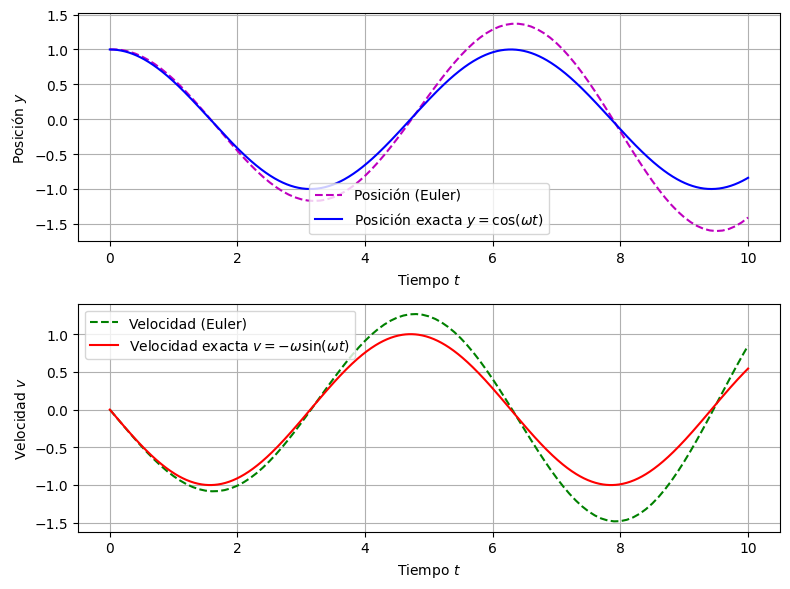

In [22]:
# Parámetros del oscilador armónico
omega = 1.0
f = lambda t, x, v: -omega**2 * x  # dv/dx = -ω² y

# Condiciones iniciales
t0, x0, v0 = 0, 1, 0  # y(0) = 1, v(0) = 0
h = 0.1
t_end = 10

# Resolver con Euler
t, x, v = Euler_orden2(f, t0, x0, v0, h, t_end)

# Solución exacta para comparación
t_exact = np.linspace(t0, t_end, 1000)
x_exact = np.cos(omega * t_exact)
v_exact = -omega * np.sin(omega * t_exact)

# Graficar resultados
plt.figure(figsize=(8, 6))

plt.subplot(2, 1, 1)
plt.plot(t, x, 'm--', label='Posición (Euler)')
plt.plot(t_exact, x_exact, 'b-', label='Posición exacta $y = \cos(\omega t)$')
plt.xlabel('Tiempo $t$')
plt.ylabel('Posición $y$')
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(t, v, 'g--', label='Velocidad (Euler)')
plt.plot(t_exact, v_exact, 'r-', label='Velocidad exacta $v = -\omega \sin(\omega t)$')
plt.xlabel('Tiempo $t$')
plt.ylabel('Velocidad $v$')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


# Método de Euler para EDOs de Segundo Orden: Formulación Matricial

Cuando trabajamos con ecuaciones diferenciales de segundo orden o con sistemas de ecuaciones diferenciales, la notación matricial proporciona una forma elegante y compacta de expresar tanto el sistema como el método numérico.

Consideremos una ecuación diferencial de segundo orden en su forma general:

$$\frac{d^2y}{dx^2} = f\left(x, y, \frac{dy}{dx}\right)$$

La transformamos en un sistema de primer orden definiendo un vector de estado:

$$\mathbf{Y} = \begin{bmatrix} y_1 \\ y_2 \end{bmatrix} = \begin{bmatrix} y \\ \frac{dy}{dx} \end{bmatrix}$$

La derivada de este vector será:

$$\frac{d\mathbf{Y}}{dx} = \begin{bmatrix} \frac{dy_1}{dx} \\ \frac{dy_2}{dx} \end{bmatrix} = \begin{bmatrix} y_2 \\ f(x, y_1, y_2) \end{bmatrix} = \mathbf{F}(x, \mathbf{Y})$$

### Método de Euler en forma matricial

El método de Euler para este sistema se expresa como:

$$\mathbf{Y}_{n+1} = \mathbf{Y}_n + h \cdot \mathbf{F}(x_n, \mathbf{Y}_n)$$

Expandiendo:

$$\begin{bmatrix} y_{1,n+1} \\ y_{2,n+1} \end{bmatrix} = \begin{bmatrix} y_{1,n} \\ y_{2,n} \end{bmatrix} + h \cdot \begin{bmatrix} y_{2,n} \\ f(x_n, y_{1,n}, y_{2,n}) \end{bmatrix}$$

### Caso especial: Sistemas lineales

Para sistemas lineales de segundo orden, la ecuación a menudo tiene la forma:

$$\frac{d^2y}{dx^2} + a\frac{dy}{dx} + by = g(x)$$

En este caso, podemos reescribirla como:

$$\frac{d\mathbf{Y}}{dx} = \mathbf{A}\mathbf{Y} + \mathbf{b}(x)$$

Donde:

$$\mathbf{A} = \begin{bmatrix} 0 & 1 \\ -b & -a \end{bmatrix}, \quad \mathbf{b}(x) = \begin{bmatrix} 0 \\ g(x) \end{bmatrix}$$

Y el método de Euler se convierte en:

$$\mathbf{Y}_{n+1} = \mathbf{Y}_n + h(\mathbf{A}\mathbf{Y}_n + \mathbf{b}(x_n)) = (I + h\mathbf{A})\mathbf{Y}_n + h\mathbf{b}(x_n)$$

Donde $I$ es la matriz identidad.

## Ejemplo: Oscilador armónico

Para el oscilador armónico $\frac{d^2y}{dx^2} + y = 0$, tenemos:

$$\mathbf{A} = \begin{bmatrix} 0 & 1 \\ -1 & 0 \end{bmatrix}, \quad \mathbf{b}(x) = \begin{bmatrix} 0 \\ 0 \end{bmatrix}$$

El método de Euler se convierte en:

$$\mathbf{Y}_{n+1} = (I + h\mathbf{A})\mathbf{Y}_n = \begin{bmatrix} 1 & h \\ -h & 1 \end{bmatrix} \mathbf{Y}_n$$

Con condiciones iniciales $\mathbf{Y}_0 = \begin{bmatrix} 0 \\ 1 \end{bmatrix}$ y paso $h = 0.1$:

$$\mathbf{Y}_1 = \begin{bmatrix} 1 & 0.1 \\ -0.1 & 1 \end{bmatrix} \begin{bmatrix} 0 \\ 1 \end{bmatrix} = \begin{bmatrix} 0.1 \\ 1 \end{bmatrix}$$

$$\mathbf{Y}_2 = \begin{bmatrix} 1 & 0.1 \\ -0.1 & 1 \end{bmatrix} \begin{bmatrix} 0.1 \\ 1 \end{bmatrix} = \begin{bmatrix} 0.2 \\ 0.99 \end{bmatrix}$$

Y así sucesivamente.


In [23]:
def euler_matrix_method(A, b, y0, h, x0, x_end):
    """
    Método de Euler matricial para resolver dY/dx = A*Y + b

    Parámetros:
    A: Matriz del sistema (numpy array de tamaño n x n)
    b: Vector constante (numpy array de tamaño n)
    y0: Vector de condiciones iniciales (numpy array de tamaño n)
    h: Tamaño del paso
    x0: Valor inicial de x
    x_end: Valor final de x

    Retorna:
    x: Vector de valores de x
    Y: Matriz donde cada fila representa el vector Y en cada paso
    """
    # Calcular el número de pasos
    n_steps = int((x_end - x0) / h)

    # Dimensión del sistema
    n = len(y0)

    # Inicializar arreglos
    x = np.zeros(n_steps + 1)
    Y = np.zeros((n_steps + 1, n))

    # Establecer condiciones iniciales
    x[0] = x0
    Y[0] = y0

    # Matriz de evolución
    evolution_matrix = np.eye(n) + h * A

    # Iterar aplicando el método de Euler
    for i in range(n_steps):
        x[i+1] = x[i] + h
        Y[i+1] = evolution_matrix @ Y[i] + h * b  # b es constante

    return x, Y


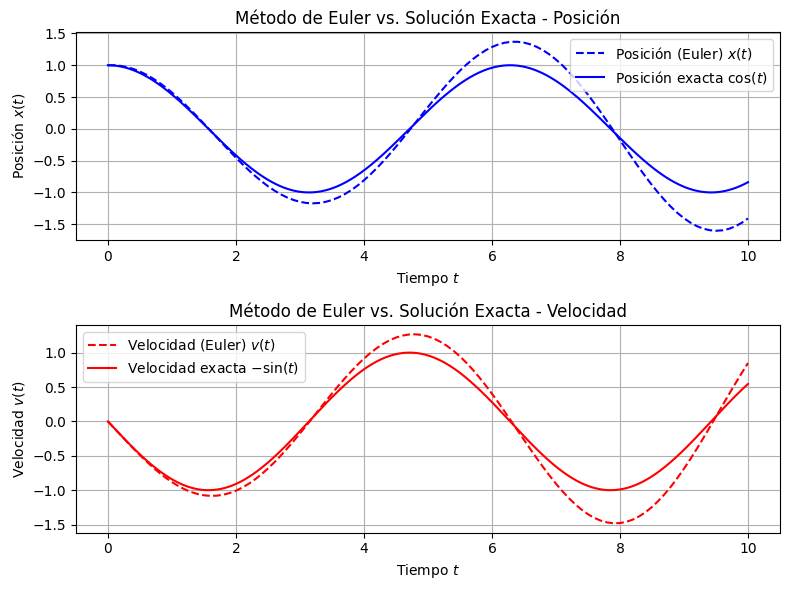

In [26]:
# Definir el sistema de ecuaciones: dY/dx = A*Y + b
A = np.array([[0, 1], [-1, 0]])  # Matriz del sistema para oscilador armónico simple
b = np.array([0, 0])  # Sistema homogéneo (sin término independiente)
y0 = np.array([1, 0])  # Condición inicial [posición, velocidad]
h = 0.1  # Paso
t0, t_end = 0, 10  # Intervalo de tiempo

# Resolver con Euler
x, Y = euler_matrix_method(A, b, y0, h, t0, t_end)

# Solución exacta del oscilador armónico
x_exact = np.linspace(t0, t_end, 1000)
y_exact = np.cos(x_exact)
v_exact = -np.sin(x_exact)

# Graficar resultados en gráficos separados
plt.figure(figsize=(8, 6))

# Gráfico de posición
plt.subplot(2, 1, 1)
plt.plot(x, Y[:, 0], 'b--', label='Posición (Euler) $x(t)$')
plt.plot(x_exact, y_exact, 'b-', label='Posición exacta $\cos(t)$')
plt.xlabel('Tiempo $t$')
plt.ylabel('Posición $x(t)$')
plt.title('Método de Euler vs. Solución Exacta - Posición')
plt.legend()
plt.grid()

# Gráfico de velocidad
plt.subplot(2, 1, 2)
plt.plot(x, Y[:, 1], 'r--', label='Velocidad (Euler) $v(t)$')
plt.plot(x_exact, v_exact, 'r-', label='Velocidad exacta $-\sin(t)$')
plt.xlabel('Tiempo $t$')
plt.ylabel('Velocidad $v(t)$')
plt.title('Método de Euler vs. Solución Exacta - Velocidad')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()